# ARTIFICIAL NEURAL NETWORK: FROM SCRATCH VS TENSORFLOW VALIDATION

## 1. DATA PREPARATION AND VISUALIZATION

### IMPORT LIBRARIES

In [2]:
# ADD PARENT DIRECTORY TO PATH TO IMPORT CUSTOM MODULES
import sys
import os
sys.path.append(os.path.abspath('..'))

# IMPORT STANDARD LIBRARIES
import numpy as np
import matplotlib.pyplot as plt

# IMPORT CUSTOM MODULES
from SRC.UTILS import generate_classification_data, configure_plots
from SRC.PREPROCESSING import StandardScaler, train_test_split
from SRC.LAYERS import Dense
from SRC.ACTIVATIONS import ReLU, Sigmoid, Tanh
from SRC.LOSSES import BinaryCrossEntropy
from SRC.OPTIMIZERS import SGD
from SRC.NEURAL_NETWORK import NeuralNetwork
from SRC.METRICS import accuracy
from EXPERIMENTS.TRAIN_MODEL import train_network

### CONFIGURE MATPLOTLIB TO STRICT REQUIREMENTS

In [3]:
configure_plots()

### GENERATE DATA

In [4]:
DF = generate_classification_data(1000)
X = DF[['FEATURE_1', 'FEATURE_2']].values
Y = DF['TARGET'].values.reshape(-1, 1)

### SPLIT AND SCALE

In [5]:
X_TRAIN, X_TEST, Y_TRAIN, Y_TEST = train_test_split(X, Y, test_size=0.2, seed=36)
SCALER = StandardScaler()
X_TRAIN = SCALER.fit_transform(X_TRAIN)
X_TEST = SCALER.transform(X_TEST)

### PLOT DATA

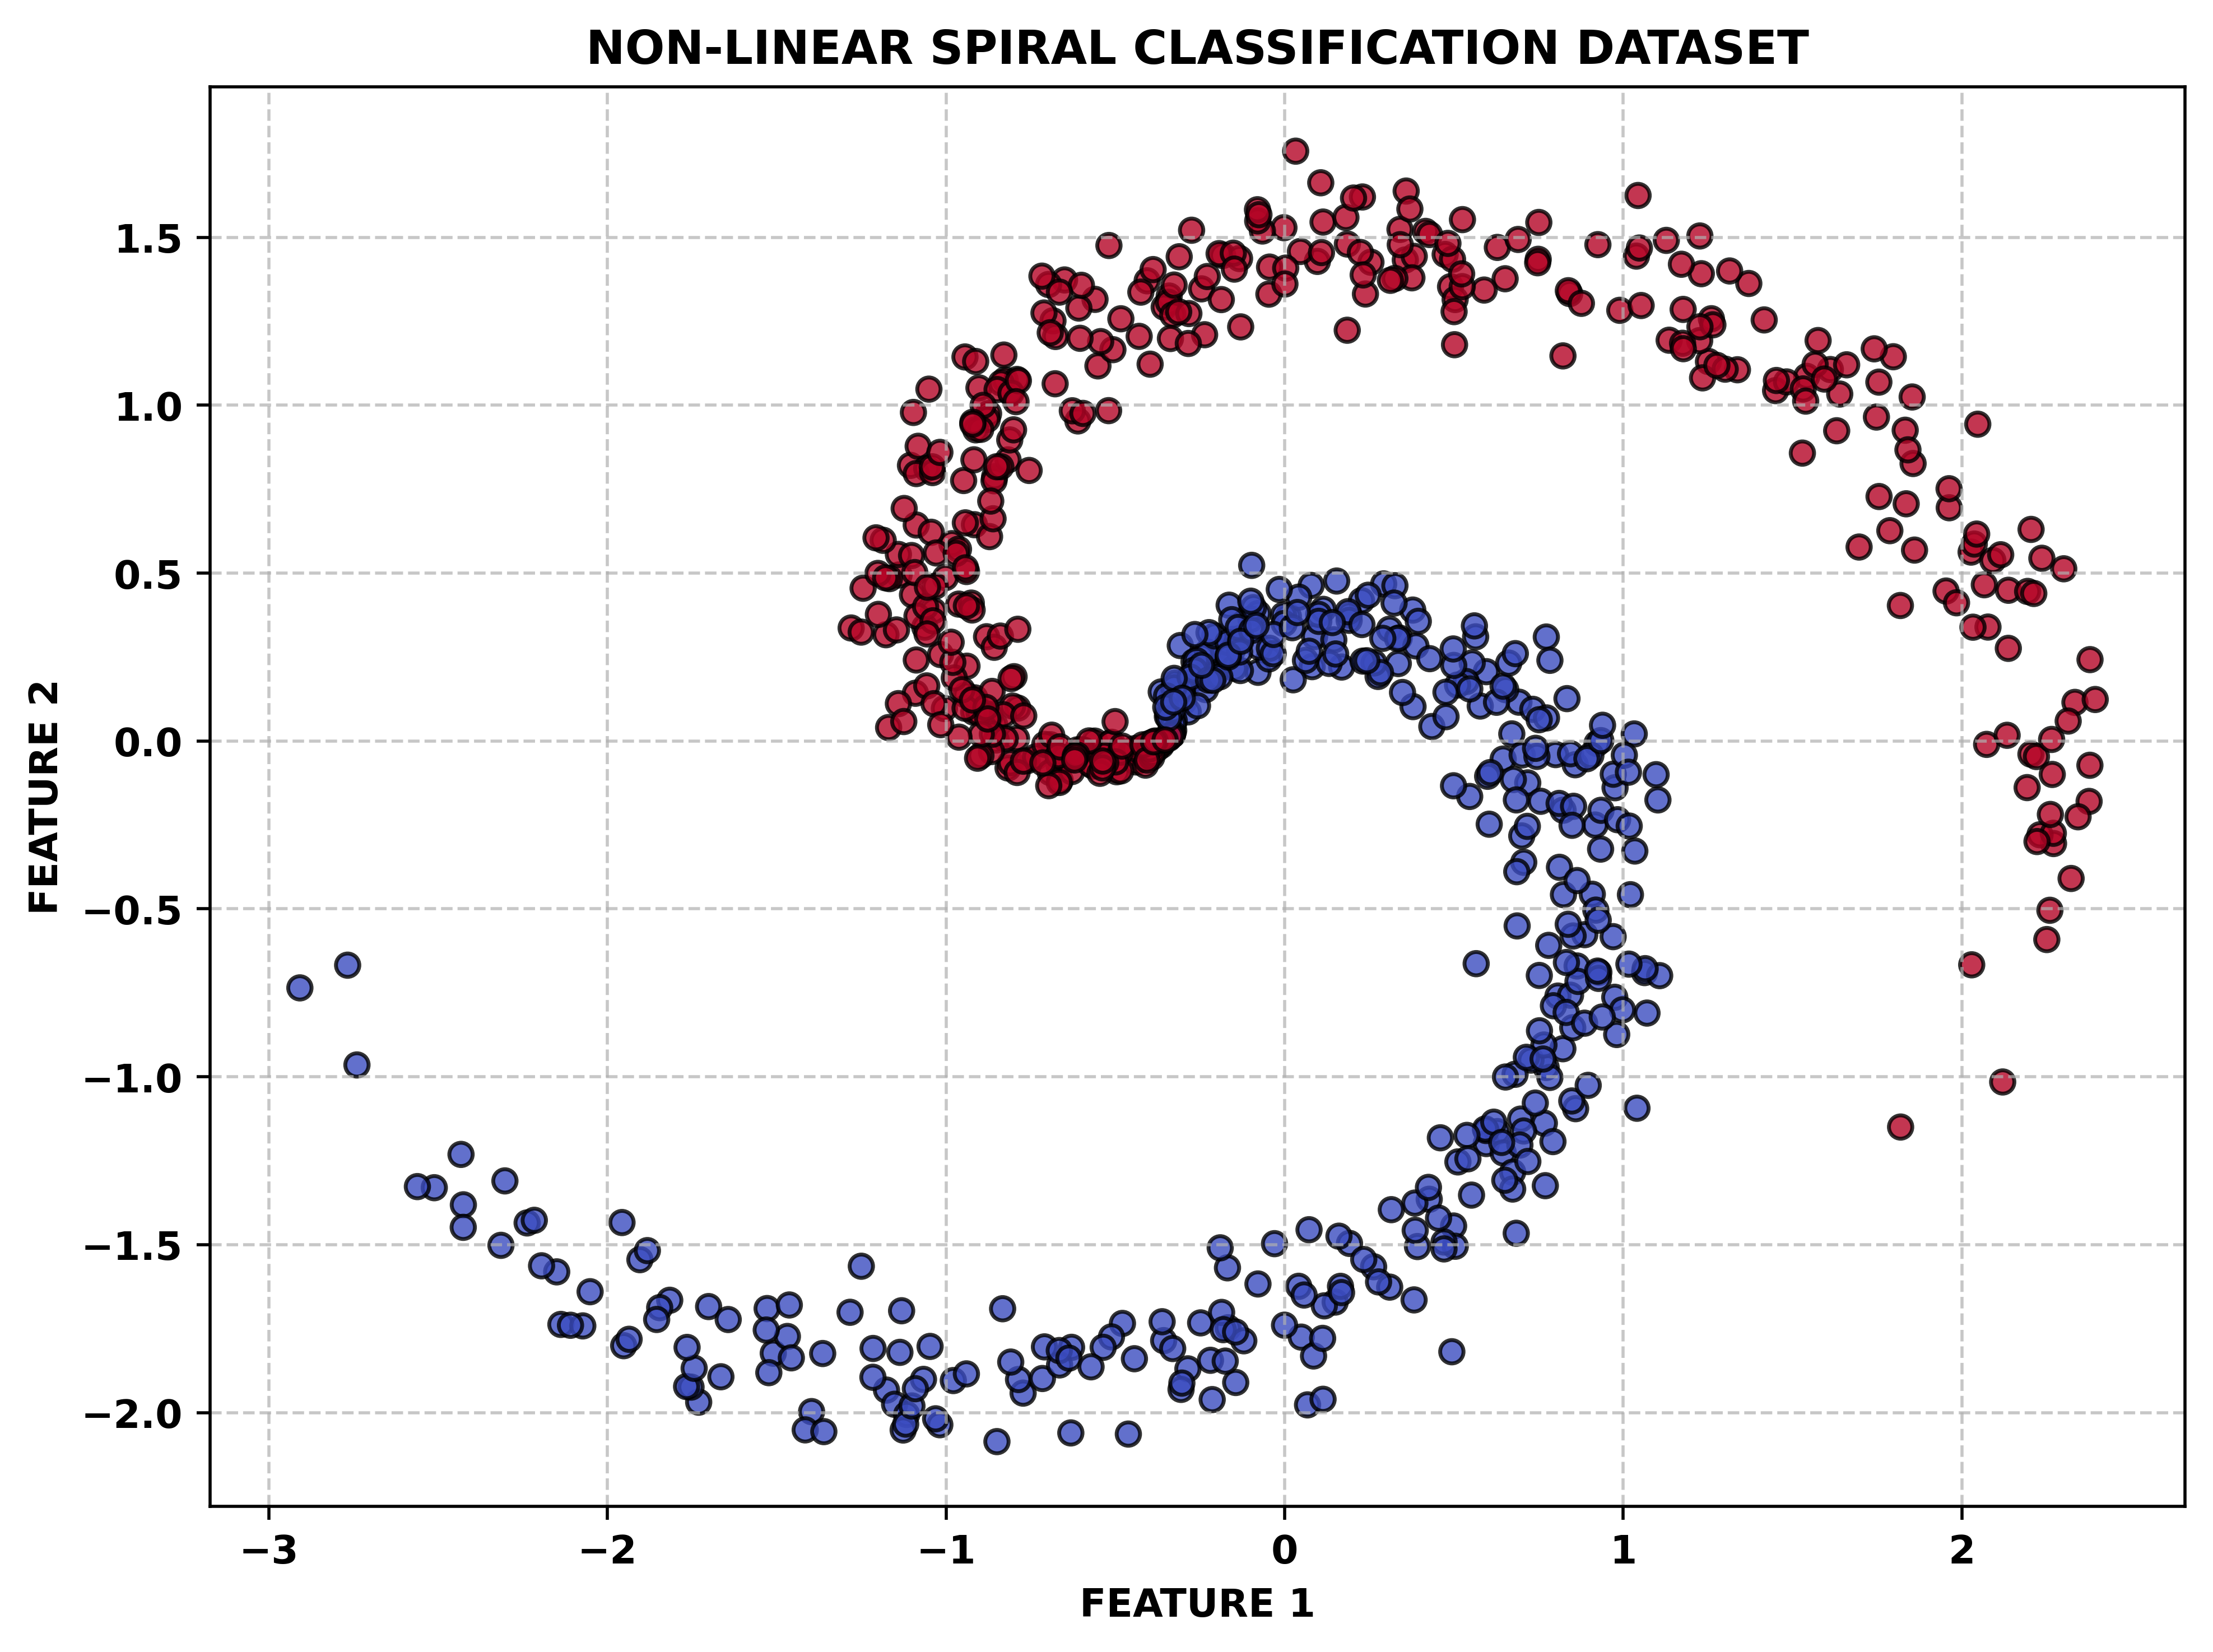

In [6]:
plt.figure(figsize=(8, 6), dpi=500)
plt.scatter(X_TRAIN[:, 0], X_TRAIN[:, 1], c=Y_TRAIN.flatten(), cmap='coolwarm', edgecolors='k', alpha=0.8)
plt.title('NON-LINEAR SPIRAL CLASSIFICATION DATASET', fontweight='bold', fontsize=12)
plt.xlabel('FEATURE 1', fontweight='bold', fontsize=10)
plt.ylabel('FEATURE 2', fontweight='bold', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 2. TRAINING THE FROM-SCRATCH IMPLEMENTATION

WE INSTANTIATE AND TRAIN OUR CUSTOM, FROM-SCRATCH NEURAL NETWORK USING FIRST PRINCIPLES. 
THE ARCHITECTURE IS A 2-16-16-1 MULTILAYER PERCEPTRON.

### HYPERPARAMETERS

In [7]:
LEARNING_RATE = 0.1
EPOCHS = 150
BATCH_SIZE = 32

### BUILD ARCHITECTURE

In [8]:
# INSTANTIATE CUSTOM MODEL
MODEL_CUSTOM = NeuralNetwork()

MODEL_CUSTOM.add(Dense(n_inputs=2, n_neurons=16, seed=36))
MODEL_CUSTOM.add(ReLU())
MODEL_CUSTOM.add(Dense(n_inputs=16, n_neurons=16, seed=36))
MODEL_CUSTOM.add(ReLU())
MODEL_CUSTOM.add(Dense(n_inputs=16, n_neurons=1, seed=36))
MODEL_CUSTOM.add(Sigmoid())

### COMPILE

In [9]:
MODEL_CUSTOM.compile(loss_function=BinaryCrossEntropy(), optimizer=SGD(learning_rate=LEARNING_RATE))

### TRAIN

In [10]:
print("TRAINING FROM-SCRATCH MODEL...")
HISTORY_CUSTOM = train_network(
    model=MODEL_CUSTOM, 
    X_train=X_TRAIN, 
    y_train=Y_TRAIN, 
    epochs=EPOCHS, 
    batch_size=BATCH_SIZE, 
    metric_fns=[accuracy]
)

TRAINING FROM-SCRATCH MODEL...
EPOCH 001/150 | LOSS: 0.4350 | ACCURACY: 0.6837
EPOCH 010/150 | LOSS: 0.0993 | ACCURACY: 0.9888
EPOCH 020/150 | LOSS: 0.0465 | ACCURACY: 0.9912
EPOCH 030/150 | LOSS: 0.0328 | ACCURACY: 0.9950
EPOCH 040/150 | LOSS: 0.0255 | ACCURACY: 0.9975
EPOCH 050/150 | LOSS: 0.0229 | ACCURACY: 0.9950
EPOCH 060/150 | LOSS: 0.0200 | ACCURACY: 0.9950
EPOCH 070/150 | LOSS: 0.0180 | ACCURACY: 0.9950
EPOCH 080/150 | LOSS: 0.0168 | ACCURACY: 0.9962
EPOCH 090/150 | LOSS: 0.0154 | ACCURACY: 0.9962
EPOCH 100/150 | LOSS: 0.0149 | ACCURACY: 0.9950
EPOCH 110/150 | LOSS: 0.0132 | ACCURACY: 0.9975
EPOCH 120/150 | LOSS: 0.0129 | ACCURACY: 0.9962
EPOCH 130/150 | LOSS: 0.0118 | ACCURACY: 0.9975
EPOCH 140/150 | LOSS: 0.0121 | ACCURACY: 0.9950
EPOCH 150/150 | LOSS: 0.0109 | ACCURACY: 0.9975

TRAINING COMPLETE IN 1.07 SECONDS


# 3. TENSORFLOW FRAMEWORK VALIDATION

TO VERIFY THE MATHEMATICAL CORRECTNESS OF OUR BACKPROPAGATION KERNEL, WE TRAIN AN IDENTICAL ARCHITECTURE USING TENSORFLOW/KERAS AND COMPARE THE CONVERGENCE BEHAVIOR.

### IMPORT TENSORFLOW

In [11]:
# IMPORT TENSORFLOW STRICTLY FOR VALIDATION
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense as KerasDense
from tensorflow.keras.optimizers import SGD as KerasSGD

### KERAS ARCHITECTURE

In [12]:
# FIX TENSORFLOW SEED FOR FAIR COMPARISON
tf.random.set_seed(36)

# BUILD EQUIVALENT KERAS ARCHITECTURE
MODEL_TF = Sequential([
    KerasDense(16, input_dim=2, activation='relu', kernel_initializer=tf.keras.initializers.HeNormal(seed=36)),
    KerasDense(16, activation='relu', kernel_initializer=tf.keras.initializers.HeNormal(seed=36)),
    KerasDense(1, activation='sigmoid', kernel_initializer=tf.keras.initializers.GlorotUniform(seed=36))
])

### COMPILE

In [13]:
# COMPILE TF MODEL
MODEL_TF.compile(
    optimizer=KerasSGD(learning_rate=LEARNING_RATE), 
    loss='binary_crossentropy', 
    metrics=['accuracy']
)

### TRAIN

In [16]:
# TRAIN TF MODEL
print("TRAINING TENSORFLOW VALIDATION MODEL...")
HISTORY_TF = MODEL_TF.fit(X_TRAIN, Y_TRAIN, epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0)

TRAINING TENSORFLOW VALIDATION MODEL...


### METRICS

In [17]:
# EXTRACT FINAL METRICS
TF_FINAL_LOSS = HISTORY_TF.history['loss'][-1]
TF_FINAL_ACC = HISTORY_TF.history['accuracy'][-1]
CUSTOM_FINAL_LOSS = HISTORY_CUSTOM['loss'][-1]
CUSTOM_FINAL_ACC = HISTORY_CUSTOM['accuracy'][-1]

print(f"CUSTOM FINAL LOSS: {CUSTOM_FINAL_LOSS:.4f} | TF FINAL LOSS: {TF_FINAL_LOSS:.4f}")
print(f"CUSTOM FINAL ACC:  {CUSTOM_FINAL_ACC:.4f} | TF FINAL ACC:  {TF_FINAL_ACC:.4f}")

CUSTOM FINAL LOSS: 0.0109 | TF FINAL LOSS: 0.0068
CUSTOM FINAL ACC:  0.9975 | TF FINAL ACC:  0.9962
